# **1. Evaluation Metrics**
- https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics

## **1-1. Metrics**

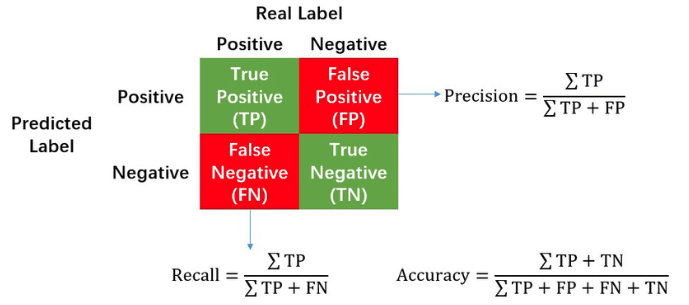



* **True Positive(TP)** : 실제 True인 정답을 True라고 예측 (정답)
* **False Positive(FP)** : 실제 False인 정답을 True라고 예측 (오답)
* **False Negative(FN)** : 실제 True인 정답을 False라고 예측 (오답)
* **True Negative(TN)** : 실제 False인 정답을 False라고 예측 (정답)

In [ ]:
import numpy as np

# Label
a = np.array([1,0,0,1,0,1,1])
# Prediction
b = np.array([0,0,0,1,1,1,0])

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

acc = accuracy_score(a, b)
print("The accuracy is {:.2f}\n".format(acc))

recall = recall_score(a, b)
print("The recall is {:.2f}\n".format(recall))

precision = precision_score(a, b)
print("The precision is {:.2f}\n".format(precision))

f1 = f1_score(a, b)
print("The f1 score is {:.2f}\n".format(f1))

print("The confusion matrix:")
print(confusion_matrix(a, b))

print("\nThe classification report is:")
print(classification_report(a, b))

> **데이터가 imbalance한 경우**

In [ ]:
import numpy as np

a = np.array([1,1,0,0,0,0,0,0])
b = np.array([0,1,0,0,0,0,0,0])

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

acc = accuracy_score(a, b)
print("The accuracy is {:.2f}\n".format(acc))

recall = recall_score(a, b)
print("The recall is {:.2f}\n".format(recall))

precision = precision_score(a, b)
print("The precision is {:.2f}\n".format(precision))

f1_score = f1_score(a, b)
print("The f1 score is {:.2f}\n".format(f1_score))

print("The confusion matrix:")
print(confusion_matrix(a, b))

print("\nThe classification report is:")
print(classification_report(a, b))

## **1-2. Draw Pretty Confusion Matrix**
* Matplotlib 패키지 사용

In [ ]:
# Load dataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

iris = load_iris()

data = iris["data"] # 실제 데이터 (모델 인풋, X)
target = iris["target"] # 예측 값 (실제 아웃풋, Y)

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=1213) # 데이터 분할

clf = MultinomialNB() # 분류기 정의
clf.fit(X_train, y_train)

prediction = clf.predict(X_test)

> **Use matplotlib**

In [ ]:
! pip3 install matplotlib # install matplotlib

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

labels = [
    "Iris-Setosa",
    "Iris-Versicolour",
    "Iris-Virginica",
]

cm2 = confusion_matrix(y_test, prediction)
sns.heatmap(cm2, annot = True, fmt = 'd',cmap = 'Reds')
plt.xlabel('Prediction')
plt.ylabel('True label')
plt.xticks([0.5,1.5,2.5], labels)
plt.yticks([0.5,1.5,2.5], labels)
plt.show()

## 1-3. Draw AUROC Curve
* 이진분류 데이터에 대해서만 AUROC커브를 그릴 수 있음

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2Fp8DII%2FbtrAxkckuuQ%2F84oY3EBYjgzxwA58VSkuLK%2Fimg.png' width='300' height='300'/>

In [ ]:
# Load dataset
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

cancer = load_breast_cancer() # 이진분류를 위한 데이터셋을 새로 로드

data = cancer["data"] # 실제 데이터 (모델 인풋, X)
target = cancer["target"] # 예측 값 (실제 아웃풋, Y)

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.33, random_state=3) # 데이터 분할

clf = MultinomialNB() # 분류기 정의
clf.fit(X_train, y_train) # 분류기 훈련

# 모델의 예측값이 1(질병이 있을 확률)일 확률을 계산한다.
y_score = clf.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import roc_curve
fpr_model, tpr_model, _ = roc_curve(y_test, y_score) # 모델에 대한 roc_curve 계산
# fpr = false positive rate
# tpr = true positive rate

ns_probs = [0 for _ in range(len(y_test))] # 기준선을 그리기 위해 모든 확률이 0인 데이터를 생성
fpr_none, tpr_none, _  = roc_curve(y_test, ns_probs) # 기준선에 대한 roc_curve 계산

In [ ]:
plt.plot(fpr_none, tpr_none, linestyle='--', label='No Skill')
plt.plot(fpr_model, tpr_model, marker='.', label='Model')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()
# show the plot
plt.show()

# **2. 실습 과제**

1. 다음 데이터셋의 accuracy, confusion matrix, classification report를 출력하는 코드를 직접 작성해보세요.
2. Matplotlib을 사용해 다음 데이터셋의 Confusion Matrix를 그려보세요.

### **2-1. Load Dataset**

In [ ]:
## Load dataset ##

!curl -k -O https://www2.aueb.gr/users/ion/data/enron-spam/preprocessed/enron1.tar.gz
! tar -xf enron1.tar.gz enron1

! pip3 install nltk
! python -m nltk.downloader all #이 부분에서 많은 시간을 소요합니다.

import glob, os

emails, labels = [], []
parition = 0

# load spam dataset
file_path = 'enron1/spam'

for fname in glob.glob(os.path.join(file_path, '*.txt')):
    with open(fname, 'r', encoding='ISO-8859-1') as f: # [!important] check encofing format
      emails.append(f.read())
      labels.append(1)

file_path = 'enron1/ham'
for fname in glob.glob(os.path.join(file_path, '*.txt')):
    with open(fname, 'r', encoding='ISO-8859-1') as f:
      emails.append(f.read())
      labels.append(0)

print('# of emails = {}\n# of labels = {}'.format(len(emails), len(labels)))

In [ ]:
## Load dataset ##

# remove number and punctuation
def letters_only(word):
    return word.isalpha()

# remove name entity
from nltk.corpus import names
all_names = set(names.words())

# lemmaization
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()


# put all together to clean texts
def clean_text(doc):
    cleaned_doc = []
    for word in doc.split(' '): # split doc. by blank (' ')
        word = word.lower() # ABD -> abd
        if letters_only(word) and word not in all_names and len(word) > 2: # remove number and punc. and name entity
            cleaned_doc.append(lemmatizer.lemmatize(word))

    return ' '.join(cleaned_doc)

cleaned_emails = [clean_text(doc) for doc in emails]

In [ ]:
## Load dataset & Model Training##

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(cleaned_emails, labels, test_size=0.33, random_state=3) # 데이터 분할

cv = CountVectorizer(stop_words='english', max_features=500)
term_docs_train = cv.fit_transform(X_train) # get counter vector for X_train
term_docs_test = cv.transform(X_test) # get counter vector for X_test

clf = MultinomialNB()
clf.fit(term_docs_train.toarray(), y_train)
y_pred = clf.predict(term_docs_test.toarray())


### **2-2. 실습 문제**

1.   스팸메일 분류기의 결과로 Accuracy, Confusion matrix, Classification report를 출력하세요.
2.   1에서 생성한 confusion matrix를 시각화하세요. (단, label 변경 필수)



In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Accuracy ##
# Your code here

## Confusion matrix ##
# Your code here

## Classification report ##
# Your code here

In [ ]:
## Plotting Confusion Matrix ##
## label명 변경 필수 ##

# Your code here